# Simple Trading Rule

In [4]:
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData
import matplotlib.pyplot as plt
%matplotlib inline

Work up a minimum example of a trend following system

Let's get some data

We can get data from various places; however for now we're going to use
prepackaged 'legacy' data stored in csv files

In [5]:
data = csvFuturesSimData()
data

csvFuturesSimData object with 252 instruments

We get stuff out of data with methods

In [6]:
print(data.get_instrument_list())
print(data.get_raw_price("SOFR").tail(5))

['AEX', 'AEX_mini', 'ALUMINIUM', 'ALUMINIUM_LME', 'AUD', 'AUDJPY', 'AUD_micro', 'BB3M', 'BBCOMM', 'BITCOIN', 'BOBL', 'BONO', 'BOVESPA', 'BRE', 'BRENT-LAST', 'BRENT_W', 'BTP', 'BTP3', 'BUND', 'BUTTER', 'BUXL', 'CAC', 'CAD', 'CAD10', 'CAD2', 'CAD5', 'CAD_micro', 'CANOLA', 'CH10', 'CHEESE', 'CHF', 'CHFJPY', 'CHF_micro', 'CHINAA-CON', 'CLP', 'CNH-onshore', 'CNH', 'COAL-GEORDIE', 'COAL', 'COCOA', 'COCOA_LDN', 'COFFEE', 'COPPER-micro', 'COPPER-mini', 'COPPER', 'COPPER_LME', 'CORN', 'CORN_mini', 'COTTON', 'COTTON2', 'CRUDE_ICE', 'CRUDE_W', 'CRUDE_W_micro', 'CRUDE_W_mini', 'CZK', 'DAX', 'DJSTX-SMALL', 'DOW', 'DOW_mini', 'DX', 'EPRA-EUROPE', 'ETHANOL', 'ETHER-micro', 'ETHEREUM', 'EU-AUTO', 'EU-BANKS', 'EU-BASIC', 'EU-CHEM', 'EU-CONSTRUCTION', 'EU-DIV30', 'EU-DJ-OIL', 'EU-DJ-TECH', 'EU-DJ-TELECOM', 'EU-DJ-UTIL', 'EU-FOOD', 'EU-HEALTH', 'EU-HOUSE', 'EU-INSURE', 'EU-MEDIA', 'EU-MID', 'EU-OIL', 'EU-REALESTATE', 'EU-RETAIL', 'EU-TECH', 'EU-TRAVEL', 'EU-UTILS', 'EUA', 'EUR', 'EURAUD', 'EURCAD', 'EURC

data can also behave in a dict like manner (though it's not a dict)

In [7]:
data['SP500']

index
1982-09-14 23:00:00     682.65
1982-09-15 23:00:00     683.15
1982-09-16 23:00:00     682.50
1982-09-17 23:00:00     681.60
1982-09-20 23:00:00     682.40
                        ...   
2024-03-28 17:00:00    5309.25
2024-03-28 18:00:00    5316.50
2024-03-28 19:00:00    5305.25
2024-03-28 20:00:00    5303.50
2024-03-28 23:00:00    5304.25
Name: price, Length: 35898, dtype: float64

In [8]:
data.keys()

['AEX',
 'AEX_mini',
 'ALUMINIUM',
 'ALUMINIUM_LME',
 'AUD',
 'AUDJPY',
 'AUD_micro',
 'BB3M',
 'BBCOMM',
 'BITCOIN',
 'BOBL',
 'BONO',
 'BOVESPA',
 'BRE',
 'BRENT-LAST',
 'BRENT_W',
 'BTP',
 'BTP3',
 'BUND',
 'BUTTER',
 'BUXL',
 'CAC',
 'CAD',
 'CAD10',
 'CAD2',
 'CAD5',
 'CAD_micro',
 'CANOLA',
 'CH10',
 'CHEESE',
 'CHF',
 'CHFJPY',
 'CHF_micro',
 'CHINAA-CON',
 'CLP',
 'CNH-onshore',
 'CNH',
 'COAL-GEORDIE',
 'COAL',
 'COCOA',
 'COCOA_LDN',
 'COFFEE',
 'COPPER-micro',
 'COPPER-mini',
 'COPPER',
 'COPPER_LME',
 'CORN',
 'CORN_mini',
 'COTTON',
 'COTTON2',
 'CRUDE_ICE',
 'CRUDE_W',
 'CRUDE_W_micro',
 'CRUDE_W_mini',
 'CZK',
 'DAX',
 'DJSTX-SMALL',
 'DOW',
 'DOW_mini',
 'DX',
 'EPRA-EUROPE',
 'ETHANOL',
 'ETHER-micro',
 'ETHEREUM',
 'EU-AUTO',
 'EU-BANKS',
 'EU-BASIC',
 'EU-CHEM',
 'EU-CONSTRUCTION',
 'EU-DIV30',
 'EU-DJ-OIL',
 'EU-DJ-TECH',
 'EU-DJ-TELECOM',
 'EU-DJ-UTIL',
 'EU-FOOD',
 'EU-HEALTH',
 'EU-HOUSE',
 'EU-INSURE',
 'EU-MEDIA',
 'EU-MID',
 'EU-OIL',
 'EU-REALESTATE',
 'EU-RE

... however this will only access prices
(note these prices have already been backadjusted for rolls)

We have extra futures data here

In [9]:
data.get_instrument_raw_carry_data("SOFR").tail(6)

,PRICE,CARRY,PRICE_CONTRACT,CARRY_CONTRACT
index,,,,
2024-03-28 16:00:00,96.425,96.405,20261200,20260900
2024-03-28 17:00:00,96.415,96.395,20261200,20260900
2024-03-28 18:00:00,96.415,96.395,20261200,20260900
2024-03-28 19:00:00,96.410,96.390,20261200,20260900
2024-03-28 20:00:00,96.405,96.385,20261200,20260900
2024-03-28 23:00:00,96.405,96.390,20261200,20260900


Technical note: csvFuturesSimData inherits from FuturesData which itself inherits from simData
The chain is 'data specific' <- 'asset class specific' <- 'generic'

Let's create a simple trading rule

No capping or scaling

In [10]:
import pandas as pd
from sysquant.estimators.vol import robust_vol_calc


def calc_ewmac_forecast(price, Lfast, Lslow=None):
    """
    Calculate the ewmac trading rule forecast, given a price and EWMA speeds
    Lfast, Lslow and vol_lookback

    """
    # price: This is the stitched price series
    # We can't use the price of the contract we're trading, or the volatility
    # will be jumpy
    # And we'll miss out on the rolldown. See
    # https://qoppac.blogspot.com/2015/05/systems-building-futures-rolling.html

    price = price.resample("1B").last()

    if Lslow is None:
        Lslow = 4 * Lfast

    # We don't need to calculate the decay parameter, just use the span
    # directly
    fast_ewma = price.ewm(span=Lfast).mean()
    slow_ewma = price.ewm(span=Lslow).mean()
    raw_ewmac = fast_ewma - slow_ewma
    vol = robust_vol_calc(price.diff())
    return raw_ewmac / vol


Try it out

(this isn't properly scaled at this stage of course)


In [11]:
instrument_code = 'SOFR'
price = data.daily_prices(instrument_code)
ewmac = calc_ewmac_forecast(price, 32, 128)
ewmac.columns = ['forecast']
ewmac.tail(5)

index
2024-03-22   -0.349853
2024-03-25   -0.378965
2024-03-26   -0.394422
2024-03-27   -0.381021
2024-03-28   -0.378662
Freq: B, Name: price, dtype: float64

Text(0.5, 0, 'Time')

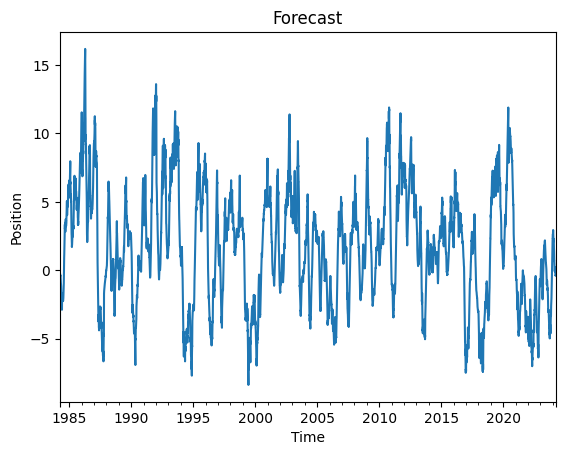

In [12]:
ewmac.plot();
plt.title('Forecast')
plt.ylabel('Position')
plt.xlabel('Time')


Did we make money?


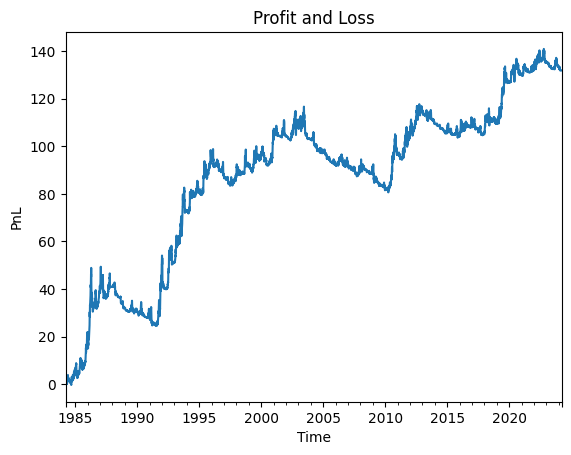

In [13]:
from systems.accounts.account_forecast import pandl_for_instrument_forecast
account = pandl_for_instrument_forecast(forecast=ewmac, price = price)
account.curve().plot();
plt.title('Profit and Loss')
plt.ylabel('PnL')
plt.xlabel('Time');

In [14]:
account.percent.stats()

[[('min', '-5.81'),
  ('max', '5.141'),
  ('median', '0'),
  ('mean', '0.01263'),
  ('std', '0.4897'),
  ('skew', '-0.2253'),
  ('ann_mean', '3.232'),
  ('ann_std', '7.836'),
  ('sharpe', '0.4125'),
  ('sortino', '0.4848'),
  ('avg_drawdown', '-11.12'),
  ('time_in_drawdown', '0.9742'),
  ('calmar', '0.08974'),
  ('avg_return_to_drawdown', '0.2907'),
  ('avg_loss', '-0.3111'),
  ('avg_gain', '0.3172'),
  ('gaintolossratio', '1.019'),
  ('profitfactor', '1.092'),
  ('hitrate', '0.5173'),
  ('t_stat', '2.634'),
  ('p_value', '0.008446')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]